In [ ]:
!pip install transformers datasets accelerate sacrebleu peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
# %%

import sys
import sacrebleu
import datasets
import os
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import accelerate
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline




In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dev-data.zip to dev-data.zip


In [ ]:
!unzip dev-data.zip

Archive:  dev-data.zip
   creating: dev-data/
  inflating: __MACOSX/._dev-data     
  inflating: dev-data/enes_dev.jsonl  
  inflating: __MACOSX/dev-data/._enes_dev.jsonl  
  inflating: dev-data/ende_dev.jsonl  
  inflating: __MACOSX/dev-data/._ende_dev.jsonl  
  inflating: dev-data/enru_dev.jsonl  
  inflating: __MACOSX/dev-data/._enru_dev.jsonl  


In [ ]:
# %%

# load data for Track 1: English → German only

def generate_track1_dev_splits(language_pair):
    dev_jsonl_path = f"dev-data/{language_pair}_dev.jsonl"
    src, tgt = language_pair[0:2], language_pair[2:4]

    noterm = []
    proper = []
    random_ = []

    with open(dev_jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            entry = json.loads(line.strip())

            noterm.append({
                src: entry[src],
                tgt: entry[tgt],
            })

            proper.append({
                src: entry[src],
                tgt: entry[tgt],
                "terms": entry.get("proper_terms", {}),
            })

            random_.append({
                src: entry[src],
                tgt: entry[tgt],
                "terms": entry.get("random_terms", {}),
            })

    return noterm, proper, random_


def generate_track1_test_splits(language_pair):
    test_jsonl_path = f"test-data/track1/{language_pair}_test.jsonl"
    src, tgt = language_pair[0:2], language_pair[2:4]

    noterm = []
    proper = []
    random_ = []

    with open(test_jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            entry = json.loads(line.strip())

            noterm.append({
                src: entry[src],
            })

            proper.append({
                src: entry[src],
                "terms": entry.get("proper_terms", {}),
            })

            random_.append({
                src: entry[src],
                "terms": entry.get("random_terms", {}),
            })

    return noterm, proper, random_


# We focus on sentence-level English → German
ende_noterm, ende_proper, ende_random = generate_track1_dev_splits("ende")

src_tgt = {
    "ende": {
        "noterm": ende_noterm,
        "proper": ende_proper,
        "random": ende_random,
        "src": "en",
        "tgt": "de",
        "src_full": "English",
        "tgt_full": "German",
    }
}

print("Number of EN-DE dev examples:", len(ende_noterm))
print("\nNo terminology example:")
print(ende_noterm[0])
print("\nProper terminology example:")
print(ende_proper[0])
print("\nRandom terminology example:")
print(ende_random[0])

Number of EN-DE dev examples: 500

No terminology example:
{'en': 'This service describes the deployed (run-time) state of SAP HANA database artifacts, for example: tables, views, or procedures, which have been created or adjusted by the SAP Integrated Development Environment (WebIDE) editors as a family of consistent design-time artifacts for all key SAP HANA platform database features.\n', 'de': 'Dieser Service beschreibt den implementierten Zustand (Laufzeitzustand) von SAP-HANA-Datenbankartefakten, z.\xa0B. Tabellen, Views oder Prozeduren, die von den SAP-Integrated-Development-Environment-Editoren (WebIDE-Editoren) als eine Familie konsistenter Entwurfszeit-Artefakte für alle wichtigen SAP-HANA-Plattform-Datenbankfunktionen erstellt oder angepasst wurden.\n'}

Proper terminology example:
{'en': 'This service describes the deployed (run-time) state of SAP HANA database artifacts, for example: tables, views, or procedures, which have been created or adjusted by the SAP Integrated De

In [ ]:
LANG_PAIR = "ende"
SRC = "en"
TGT = "de"

N_EXAMPLES = 5

dev_noterm_small = ende_noterm[:N_EXAMPLES]
dev_proper_small = ende_proper[:N_EXAMPLES]
dev_random_small = ende_random[:N_EXAMPLES]

print(len(ende_noterm))
print(dev_proper_small[0])

500
{'en': 'This service describes the deployed (run-time) state of SAP HANA database artifacts, for example: tables, views, or procedures, which have been created or adjusted by the SAP Integrated Development Environment (WebIDE) editors as a family of consistent design-time artifacts for all key SAP HANA platform database features.\n', 'de': 'Dieser Service beschreibt den implementierten Zustand (Laufzeitzustand) von SAP-HANA-Datenbankartefakten, z.\xa0B. Tabellen, Views oder Prozeduren, die von den SAP-Integrated-Development-Environment-Editoren (WebIDE-Editoren) als eine Familie konsistenter Entwurfszeit-Artefakte für alle wichtigen SAP-HANA-Plattform-Datenbankfunktionen erstellt oder angepasst wurden.\n', 'terms': {'design': 'Entwurf', 'state': 'Zustand'}}


In [ ]:
def format_terms(terms):
    if not terms:
        return ""
    return "\n".join([f"{src} -> {tgt}" for src, tgt in terms.items()])


def build_prompt(entry, src_tgt_pair="ende", prompt_type="basic"):
    source = entry["en"].strip()
    terms = entry.get("terms", {})
    term_text = format_terms(terms)

    if prompt_type == "noterm" or term_text == "":
        return (
            "Translate the sentence from English to German.\n"
            "Return only the German translation. Do not explain.\n\n"
            f"English: {source}\n"
            "German:"
        )

    if prompt_type == "basic":
        return (
            "Translate the sentence from English to German.\n"
            "Return only the German translation. Do not explain.\n"
            "Use the terminology if it is relevant.\n\n"
            f"Terminology:\n{term_text}\n\n"
            f"English: {source}\n"
            "German:"
        )

    if prompt_type == "strong":
        return (
            "Translate the sentence from English to German.\n"
            "Return only the German translation. Do not explain.\n"
            "If a source term appears in the English sentence, use the exact German target term given in the terminology list.\n\n"
            f"Terminology:\n{term_text}\n\n"
            f"English: {source}\n"
            "German:"
        )

In [ ]:
print(build_prompt(dev_proper_small[0], prompt_type="basic"))

Translate the following sentence from English to German.
Use the provided terminology when relevant.

Terminology:
design -> Entwurf
state -> Zustand

Source: This service describes the deployed (run-time) state of SAP HANA database artifacts, for example: tables, views, or procedures, which have been created or adjusted by the SAP Integrated Development Environment (WebIDE) editors as a family of consistent design-time artifacts for all key SAP HANA platform database features.

Translation:


In [ ]:
# %%

model_id = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
)

print("Loaded model:", model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded model: Qwen/Qwen2.5-1.5B-Instruct


In [ ]:
# %%

def generate_translations(inputs, prompt_type, batch_size=2, max_new_tokens=160):
    outputs = []

    for start in range(0, len(inputs), batch_size):
        batch = inputs[start:start + batch_size]

        prompts = [
            build_prompt(entry, prompt_type=prompt_type)
            for entry in batch
        ]

        messages_list = [
            [{"role": "user", "content": prompt}]
            for prompt in prompts
        ]

        texts = [
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
            for messages in messages_list
        ]

        model_inputs = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        for i in range(len(batch)):
            input_len = model_inputs.input_ids[i].shape[0]
            output_ids = generated_ids[i][input_len:]
            translation = tokenizer.decode(
                output_ids,
                skip_special_tokens=True
            ).strip()
            outputs.append(translation)

    return outputs

In [ ]:
# %%

test_outputs = generate_translations(
    dev_proper_small[:2],
    prompt_type="basic",
    batch_size=1,
    max_new_tokens=160
)

for i, out in enumerate(test_outputs):
    print("SOURCE:", dev_proper_small[i]["en"])
    print("TERMS:", dev_proper_small[i]["terms"])
    print("OUTPUT:", out)
    print("REFERENCE:", dev_proper_small[i]["de"])
    print("-" * 80)

SOURCE: This service describes the deployed (run-time) state of SAP HANA database artifacts, for example: tables, views, or procedures, which have been created or adjusted by the SAP Integrated Development Environment (WebIDE) editors as a family of consistent design-time artifacts for all key SAP HANA platform database features.

TERMS: {'design': 'Entwurf', 'state': 'Zustand'}
OUTPUT: Dieses Service beschreibt den ausgeführten (betrieblichen) Zustand der SAP HANA-Datenbank-Objekte, z.B. Tabellen, Ansichten oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden, als Familie konstanter Entwurfszeitobjekte für alle Schlüsselfunktionen des SAP HANA Plattforms Datenbankfeatures.
REFERENCE: Dieser Service beschreibt den implementierten Zustand (Laufzeitzustand) von SAP-HANA-Datenbankartefakten, z. B. Tabellen, Views oder Prozeduren, die von den SAP-Integrated-Development-Environment-Editoren (WebIDE-Editoren) als eine Familie konsist

In [ ]:
# %%

N_EVAL = 20

eval_noterm = ende_noterm[:N_EVAL]
eval_proper = ende_proper[:N_EVAL]
eval_random = ende_random[:N_EVAL]

print("Evaluation examples:", len(eval_proper))

Evaluation examples: 20


In [ ]:
# %%

outputs_noterm = generate_translations(
    eval_noterm,
    prompt_type="noterm",
    batch_size=2
)

outputs_basic = generate_translations(
    eval_proper,
    prompt_type="basic",
    batch_size=2
)

outputs_strong = generate_translations(
    eval_proper,
    prompt_type="strong",
    batch_size=2
)

In [ ]:
# %%

references = [
    entry["de"].strip()
    for entry in eval_proper
]

bleu_noterm = sacrebleu.corpus_bleu(
    outputs_noterm,
    [references]
)

bleu_basic = sacrebleu.corpus_bleu(
    outputs_basic,
    [references]
)

bleu_strong = sacrebleu.corpus_bleu(
    outputs_strong,
    [references]
)

print("BLEU scores")
print("No terminology:", bleu_noterm.score)
print("Basic prompting:", bleu_basic.score)
print("Strong prompting:", bleu_strong.score)

BLEU scores
No terminology: 17.210575008568735
Basic prompting: 24.452302248745504
Strong prompting: 19.77026715978557


In [ ]:
def terminology_accuracy(outputs, examples):
    total_terms = 0
    matched_terms = 0

    for output, example in zip(outputs, examples):
        terms = example.get("terms", {})

        for source_term, target_term in terms.items():
            total_terms += 1
            if target_term.lower() in output.lower():
                matched_terms += 1

    if total_terms == 0:
        return 0

    return matched_terms / total_terms


term_acc_noterm = terminology_accuracy(outputs_noterm, eval_proper)
term_acc_basic = terminology_accuracy(outputs_basic, eval_proper)
term_acc_strong = terminology_accuracy(outputs_strong, eval_proper)

print("Terminology accuracy")
print("No terminology:", term_acc_noterm)
print("Basic prompting:", term_acc_basic)
print("Strong prompting:", term_acc_strong)

Terminology accuracy
No terminology: 0.2608695652173913
Basic prompting: 0.8260869565217391
Strong prompting: 0.8260869565217391


In [ ]:
# %%

results_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting"
    ],
    "BLEU": [
        bleu_noterm.score,
        bleu_basic.score,
        bleu_strong.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm,
        term_acc_basic,
        term_acc_strong
    ]
})

results_df

,Method,BLEU,Terminology Accuracy
0,No terminology,17.210575,0.260870
1,Basic prompting,24.452302,0.826087
2,Strong prompting,19.770267,0.826087


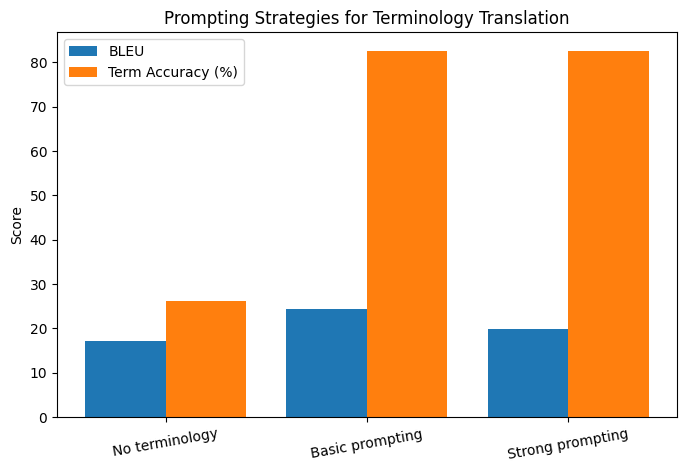

In [ ]:
# %%

plt.figure(figsize=(8, 5))

x = np.arange(len(results_df))

plt.bar(
    x - 0.2,
    results_df["BLEU"],
    width=0.4,
    label="BLEU"
)

plt.bar(
    x + 0.2,
    results_df["Terminology Accuracy"] * 100,
    width=0.4,
    label="Term Accuracy (%)"
)

plt.xticks(x, results_df["Method"], rotation=10)

plt.ylabel("Score")
plt.title("Prompting Strategies for Terminology Translation")
plt.legend()

plt.show()

In [ ]:
few_shot_example = """
English: The system checks the connection state.
German: Das System überprüft den Verbindungszustand.
"""

def build_fewshot_prompt(entry):
    source = entry["en"].strip()
    terms = entry.get("terms", {})

    term_text = format_terms(terms)

    return (
        "Translate the sentence from English to German.\n"
        "Return only the German translation.\n"
        "Use the terminology when relevant.\n\n"
        "Example:\n"
        f"{few_shot_example}\n\n"
        f"Terminology:\n{term_text}\n\n"
        f"English: {source}\n"
        "German:"
    )

In [ ]:
def generate_fewshot(inputs, batch_size=2):
    outputs = []

    for start in range(0, len(inputs), batch_size):
        batch = inputs[start:start + batch_size]

        prompts = [
            build_fewshot_prompt(entry)
            for entry in batch
        ]

        messages_list = [
            [{"role": "user", "content": prompt}]
            for prompt in prompts
        ]

        texts = [
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
            for messages in messages_list
        ]

        model_inputs = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=120,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        for i in range(len(batch)):
            input_len = model_inputs.input_ids[i].shape[0]
            output_ids = generated_ids[i][input_len:]

            output = tokenizer.decode(
                output_ids,
                skip_special_tokens=True
            ).strip()

            outputs.append(output)

    return outputs

In [ ]:
outputs_fewshot = generate_fewshot(eval_proper)

bleu_fewshot = sacrebleu.corpus_bleu(
    outputs_fewshot,
    [references]
)

term_acc_fewshot = terminology_accuracy(
    outputs_fewshot,
    eval_proper
)

print("Few-shot BLEU:", bleu_fewshot.score)
print("Few-shot terminology accuracy:", term_acc_fewshot)

Few-shot BLEU: 17.158710527000025
Few-shot terminology accuracy: 0.6086956521739131


In [ ]:
eval_random = ende_random[:20]

references_random = [
    entry["de"].strip()
    for entry in eval_random
]

outputs_random = generate_translations(
    eval_random,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

bleu_random = sacrebleu.corpus_bleu(
    outputs_random,
    [references_random]
)

term_acc_random = terminology_accuracy(
    outputs_random,
    eval_random
)

print("Random terminology BLEU:", bleu_random.score)
print("Random terminology accuracy:", term_acc_random)

Random terminology BLEU: 20.9352248324421
Random terminology accuracy: 0.6071428571428571


In [ ]:
!pip install peft trl bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.9 MB/s eta 0:00:00


In [ ]:
from datasets import Dataset

def format_lora_example(example):
    source = example["en"].strip()
    target = example["de"].strip()
    terms = example.get("terms", {})
    term_text = format_terms(terms)

    prompt = (
        "Translate the sentence from English to German.\n"
        "Return only the German translation. Do not explain.\n"
        "Use the terminology if it is relevant.\n\n"
        f"Terminology:\n{term_text}\n\n"
        f"English: {source}\n"
        "German:"
    )

    return {
        "text": prompt + " " + target
    }

# Use terminology examples only
train_examples = ende_proper[:400]
eval_examples = ende_proper[400:450]

train_texts = [format_lora_example(ex) for ex in train_examples]
eval_texts = [format_lora_example(ex) for ex in eval_examples]

train_dataset = Dataset.from_list(train_texts)
eval_dataset = Dataset.from_list(eval_texts)

print(train_dataset[0]["text"][:1000])
print("Train size:", len(train_dataset))
print("Eval size:", len(eval_dataset))

Translate the sentence from English to German.
Return only the German translation. Do not explain.
Use the terminology if it is relevant.

Terminology:
design -> Entwurf
state -> Zustand

English: This service describes the deployed (run-time) state of SAP HANA database artifacts, for example: tables, views, or procedures, which have been created or adjusted by the SAP Integrated Development Environment (WebIDE) editors as a family of consistent design-time artifacts for all key SAP HANA platform database features.
German: Dieser Service beschreibt den implementierten Zustand (Laufzeitzustand) von SAP-HANA-Datenbankartefakten, z. B. Tabellen, Views oder Prozeduren, die von den SAP-Integrated-Development-Environment-Editoren (WebIDE-Editoren) als eine Familie konsistenter Entwurfszeit-Artefakte für alle wichtigen SAP-HANA-Plattform-Datenbankfunktionen erstellt oder angepasst wurden.
Train size: 400
Eval size: 50


In [ ]:
!pip install -U torchao -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.9 MB/s eta 0:00:00


In [ ]:
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

# Free a bit of memory before training
torch.cuda.empty_cache()

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model_lora = get_peft_model(model, lora_config)
model_lora.print_trainable_parameters()

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [ ]:
training_args = SFTConfig(
    output_dir="qwen_lora_terminology",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    max_length=512,
    logging_steps=10,
    save_steps=100,
    report_to="none",
)

trainer = SFTTrainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.529501
20,1.602022
30,1.095051
40,0.983368
50,1.040207
60,0.992896
70,0.922721
80,0.988635
90,0.954259
100,0.968636


TrainOutput(global_step=100, training_loss=1.207729730606079, metrics={'train_runtime': 254.071, 'train_samples_per_second': 1.574, 'train_steps_per_second': 0.394, 'total_flos': 237167056097280.0, 'train_loss': 1.207729730606079})

In [ ]:
trainer.model.save_pretrained("qwen_lora_terminology_adapter")
tokenizer.save_pretrained("qwen_lora_terminology_adapter")
print("Saved LoRA adapter.")

Saved LoRA adapter.


In [ ]:
# Use trained LoRA model for generation
model = trainer.model
model.eval()

outputs_lora_basic = generate_translations(
    eval_proper,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

bleu_lora = sacrebleu.corpus_bleu(
    outputs_lora_basic,
    [references]
)

term_acc_lora = terminology_accuracy(
    outputs_lora_basic,
    eval_proper
)

print("LoRA BLEU:", bleu_lora.score)
print("LoRA terminology accuracy:", term_acc_lora)

LoRA BLEU: 19.38695176590484
LoRA terminology accuracy: 0.782608695652174


In [ ]:
results_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Few-shot prompting",
        "Random terminology",
        "LoRA adaptation"
    ],
    "BLEU": [
        bleu_noterm.score,
        bleu_basic.score,
        bleu_strong.score,
        bleu_fewshot.score,
        bleu_random.score,
        bleu_lora.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm,
        term_acc_basic,
        term_acc_strong,
        term_acc_fewshot,
        term_acc_random,
        term_acc_lora
    ]
})

results_df

,Method,BLEU,Terminology Accuracy
0,No terminology,17.210575,0.260870
1,Basic prompting,24.452302,0.826087
2,Strong prompting,19.770267,0.826087
3,Few-shot prompting,17.158711,0.608696
4,Random terminology,20.935225,0.607143
5,LoRA adaptation,19.386952,0.782609


In [ ]:
results_df.to_csv("nlp2_final_results.csv", index=False)

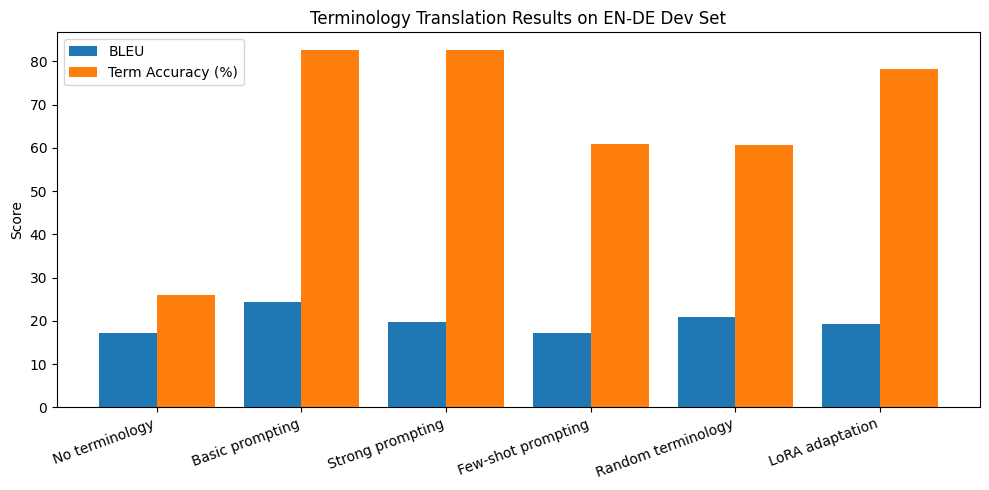

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(results_df))

plt.bar(x - 0.2, results_df["BLEU"], width=0.4, label="BLEU")
plt.bar(x + 0.2, results_df["Terminology Accuracy"] * 100, width=0.4, label="Term Accuracy (%)")

plt.xticks(x, results_df["Method"], rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Terminology Translation Results on EN-DE Dev Set")
plt.legend()
plt.tight_layout()
plt.savefig("prompt_lora_results.png", dpi=300)
plt.show()

In [42]:
# 50-example evaluation setup

N_EVAL_50 = 50

eval_noterm_50 = ende_noterm[:N_EVAL_50]
eval_proper_50 = ende_proper[:N_EVAL_50]
eval_random_50 = ende_random[:N_EVAL_50]

references_50 = [
    entry["de"].strip()
    for entry in eval_proper_50
]

print("Evaluation size:", N_EVAL_50)

Evaluation size: 50


In [43]:
# Generate outputs for 50 examples

outputs_noterm_50 = generate_translations(
    eval_noterm_50,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

outputs_basic_50 = generate_translations(
    eval_proper_50,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

outputs_strong_50 = generate_translations(
    eval_proper_50,
    prompt_type="strong",
    batch_size=2,
    max_new_tokens=160
)

outputs_fewshot_50 = generate_fewshot(
    eval_proper_50,
    batch_size=2
)

outputs_random_50 = generate_translations(
    eval_random_50,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

# Use trained LoRA model
model = trainer.model
model.eval()

outputs_lora_50 = generate_translations(
    eval_proper_50,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [44]:
results_outputs_50_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_50],
    "reference": references_50,
    "noterm": outputs_noterm_50,
    "basic": outputs_basic_50,
    "strong": outputs_strong_50,
    "fewshot": outputs_fewshot_50,
    "random_terms": outputs_random_50,
    "lora_basic": outputs_lora_50,
})

results_outputs_50_df.to_csv("nlp2_outputs_50.csv", index=False)
print("Saved nlp2_outputs_50.csv")

Saved nlp2_outputs_50.csv


In [45]:
bleu_noterm_50 = sacrebleu.corpus_bleu(outputs_noterm_50, [references_50])
bleu_basic_50 = sacrebleu.corpus_bleu(outputs_basic_50, [references_50])
bleu_strong_50 = sacrebleu.corpus_bleu(outputs_strong_50, [references_50])
bleu_fewshot_50 = sacrebleu.corpus_bleu(outputs_fewshot_50, [references_50])
bleu_random_50 = sacrebleu.corpus_bleu(outputs_random_50, [references_50])
bleu_lora_basic_50 = sacrebleu.corpus_bleu(outputs_lora_50, [references_50])

term_acc_noterm_50 = terminology_accuracy(outputs_noterm_50, eval_proper_50)
term_acc_basic_50 = terminology_accuracy(outputs_basic_50, eval_proper_50)
term_acc_strong_50 = terminology_accuracy(outputs_strong_50, eval_proper_50)
term_acc_fewshot_50 = terminology_accuracy(outputs_fewshot_50, eval_proper_50)

term_acc_random_given_50 = terminology_accuracy(outputs_random_50, eval_random_50)
term_acc_random_proper_50 = terminology_accuracy(outputs_random_50, eval_proper_50)

term_acc_lora_basic_50 = terminology_accuracy(outputs_lora_50, eval_proper_50)

print("50-example results")
print("No terminology:", bleu_noterm_50.score, term_acc_noterm_50)
print("Basic prompting:", bleu_basic_50.score, term_acc_basic_50)
print("Strong prompting:", bleu_strong_50.score, term_acc_strong_50)
print("Few-shot prompting:", bleu_fewshot_50.score, term_acc_fewshot_50)
print("Random terminology, adherence to random terms:", bleu_random_50.score, term_acc_random_given_50)
print("Random terminology, adherence to proper terms:", bleu_random_50.score, term_acc_random_proper_50)
print("LoRA + basic prompt:", bleu_lora_basic_50.score, term_acc_lora_basic_50)

50-example results
No terminology: 15.3023964703802 0.22033898305084745
Basic prompting: 15.57863409346995 0.7457627118644068
Strong prompting: 17.386103788561716 0.6949152542372882
Few-shot prompting: 15.866197030764313 0.6271186440677966
Random terminology, adherence to random terms: 13.575834220780775 0.6578947368421053
Random terminology, adherence to proper terms: 13.575834220780775 0.288135593220339
LoRA + basic prompt: 15.57863409346995 0.7457627118644068


In [46]:
metrics_50_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Few-shot prompting",
        "Random terminology",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_50.score,
        bleu_basic_50.score,
        bleu_strong_50.score,
        bleu_fewshot_50.score,
        bleu_random_50.score,
        bleu_lora_basic_50.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_50,
        term_acc_basic_50,
        term_acc_strong_50,
        term_acc_fewshot_50,
        term_acc_random_given_50,
        term_acc_lora_basic_50
    ]
})

metrics_50_df

,Method,BLEU,Terminology Accuracy
0,No terminology,15.302396,0.220339
1,Basic prompting,15.578634,0.745763
2,Strong prompting,17.386104,0.694915
3,Few-shot prompting,15.866197,0.627119
4,Random terminology,13.575834,0.657895
5,LoRA + basic prompt,15.578634,0.745763


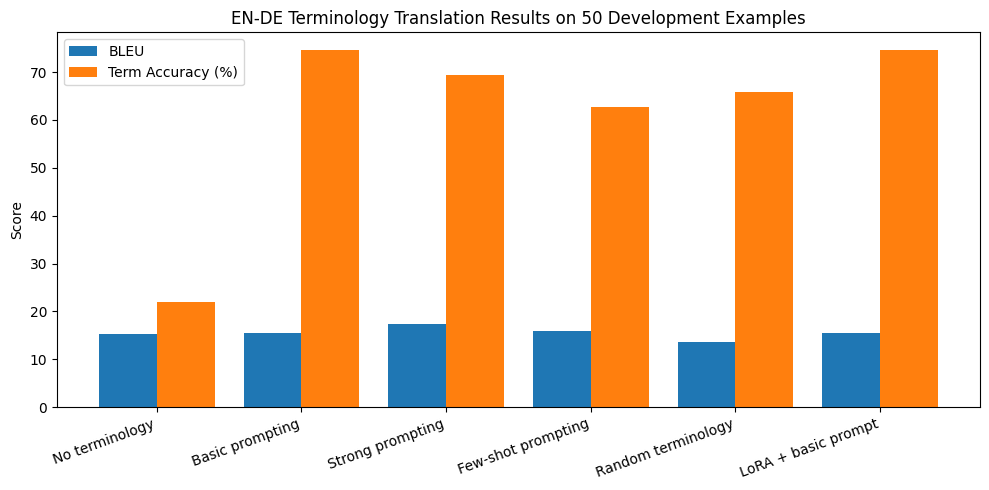

In [47]:
metrics_50_df.to_csv("nlp2_final_metrics_50.csv", index=False)

plt.figure(figsize=(10, 5))

x = np.arange(len(metrics_50_df))

plt.bar(x - 0.2, metrics_50_df["BLEU"], width=0.4, label="BLEU")
plt.bar(x + 0.2, metrics_50_df["Terminology Accuracy"] * 100, width=0.4, label="Term Accuracy (%)")

plt.xticks(x, metrics_50_df["Method"], rotation=20, ha="right")
plt.ylabel("Score")
plt.title("EN-DE Terminology Translation Results on 50 Development Examples")
plt.legend()
plt.tight_layout()

plt.savefig("prompt_lora_results_50.png", dpi=300)
plt.show()

In [48]:
print(outputs_basic_50[0])
print("=" * 80)
print(outputs_lora_50[0])

print(outputs_basic_50 == outputs_lora_50)

Dieses Service beschreibt den ausgeführt- oder in Betrieb befindlichen (betriebszeit-) Zustand von SAP HANA-Datenbankartefakten, z.B. Tabellen, Views oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden und als Familie konstanter Entwurfszeit-artefakte für alle Schlüssel SAP HANA Plattform-Datenbankfunktionen verwendet werden.
Dieses Service beschreibt den ausgeführt- oder in Betrieb befindlichen (betriebszeit-) Zustand von SAP HANA-Datenbankartefakten, z.B. Tabellen, Views oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden und als Familie konstanter Entwurfszeit-artefakte für alle Schlüssel SAP HANA Plattform-Datenbankfunktionen verwendet werden.
True


In [49]:
for i in range(5):
    print("Example", i)
    print("Basic:", outputs_basic_50[i])
    print("LoRA :", outputs_lora_50[i])
    print("-" * 80)

Example 0
Basic: Dieses Service beschreibt den ausgeführt- oder in Betrieb befindlichen (betriebszeit-) Zustand von SAP HANA-Datenbankartefakten, z.B. Tabellen, Views oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden und als Familie konstanter Entwurfszeit-artefakte für alle Schlüssel SAP HANA Plattform-Datenbankfunktionen verwendet werden.
LoRA : Dieses Service beschreibt den ausgeführt- oder in Betrieb befindlichen (betriebszeit-) Zustand von SAP HANA-Datenbankartefakten, z.B. Tabellen, Views oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden und als Familie konstanter Entwurfszeit-artefakte für alle Schlüssel SAP HANA Plattform-Datenbankfunktionen verwendet werden.
--------------------------------------------------------------------------------
Example 1
Basic: Kontrollieren Sie Ihre Datenflussanalyse durch eine Kontrolle und verbessern Sie die Analyse der Ursac

In [52]:
# ============================================================
# VERIFIED 50-EXAMPLE EVALUATION WITH SEPARATE BASE / LORA MODELS
# ============================================================

In [53]:
# Reload a clean base model so it is separate from the LoRA model

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
)

base_model.eval()

print("Clean base model loaded")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Clean base model loaded


In [54]:
def generate_translations_with_model(
    input_data,
    generation_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
):
    outputs = []

    for start in range(0, len(input_data), batch_size):
        batch = input_data[start:start + batch_size]

        prompts = []

        for entry in batch:
            prompt = build_prompt(entry, LANG_PAIR, prompt_type=prompt_type)
            messages = [{"role": "user", "content": prompt}]

            text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            prompts.append(text)

        model_inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(generation_model.device)

        with torch.no_grad():
            generated_ids = generation_model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        for i in range(len(batch)):
            input_length = model_inputs.input_ids[i].shape[0]
            output_ids = generated_ids[i][input_length:]
            output_text = tokenizer.decode(output_ids, skip_special_tokens=True).strip()
            outputs.append(output_text)

    return outputs

In [55]:
outputs_noterm_50_verified = generate_translations_with_model(
    eval_noterm_50,
    base_model,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

outputs_basic_50_verified = generate_translations_with_model(
    eval_proper_50,
    base_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

outputs_strong_50_verified = generate_translations_with_model(
    eval_proper_50,
    base_model,
    prompt_type="strong",
    batch_size=2,
    max_new_tokens=160
)

outputs_random_50_verified = generate_translations_with_model(
    eval_random_50,
    base_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [56]:
lora_model = trainer.model
lora_model.eval()

outputs_lora_basic_50_verified = generate_translations_with_model(
    eval_proper_50,
    lora_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [57]:
print("Are base basic and LoRA basic identical?")
print(outputs_basic_50_verified == outputs_lora_basic_50_verified)

for i in range(3):
    print("Example", i)
    print("BASE:", outputs_basic_50_verified[i])
    print("LORA:", outputs_lora_basic_50_verified[i])
    print("-" * 80)

Are base basic and LoRA basic identical?
False
Example 0
BASE: Dieses Service beschreibt den ausgeführten (betrieblichen) Zustand der SAP HANA-Datenbank-Objekte, z.B. Tabellen, Ansichten oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden, als Familie konstanter Entwurfszeitobjekte für alle Schlüsselfunktionen des SAP HANA Plattforms Datenbankfeatures.
LORA: Dieses Service beschreibt den ausgeführt- oder in Betrieb befindlichen (betriebszeit-) Zustand von SAP HANA-Datenbankartefakten, z.B. Tabellen, Views oder Prozeduren, die durch das SAP Integratete Entwicklungssystem (WebIDE)-Editor erstellt oder geändert wurden und als Familie konstanter Entwurfszeit-artefakte für alle Schlüssel SAP HANA Plattform-Datenbankfunktionen verwendet werden.
--------------------------------------------------------------------------------
Example 1
BASE: Kontrolliere bitte einen Überwachungsbesuch, um eine Gesundheitsdiagnose durchzuführen und bes

In [58]:
# Verified metrics for 50 examples

bleu_noterm_50_verified = sacrebleu.corpus_bleu(outputs_noterm_50_verified, [references_50])
bleu_basic_50_verified = sacrebleu.corpus_bleu(outputs_basic_50_verified, [references_50])
bleu_strong_50_verified = sacrebleu.corpus_bleu(outputs_strong_50_verified, [references_50])
bleu_random_50_verified = sacrebleu.corpus_bleu(outputs_random_50_verified, [references_50])
bleu_lora_basic_50_verified = sacrebleu.corpus_bleu(outputs_lora_basic_50_verified, [references_50])

term_acc_noterm_50_verified = terminology_accuracy(outputs_noterm_50_verified, eval_proper_50)
term_acc_basic_50_verified = terminology_accuracy(outputs_basic_50_verified, eval_proper_50)
term_acc_strong_50_verified = terminology_accuracy(outputs_strong_50_verified, eval_proper_50)

term_acc_random_given_50_verified = terminology_accuracy(outputs_random_50_verified, eval_random_50)
term_acc_random_proper_50_verified = terminology_accuracy(outputs_random_50_verified, eval_proper_50)

term_acc_lora_basic_50_verified = terminology_accuracy(outputs_lora_basic_50_verified, eval_proper_50)

print("VERIFIED 50-example results")
print("No terminology:", bleu_noterm_50_verified.score, term_acc_noterm_50_verified)
print("Basic prompting:", bleu_basic_50_verified.score, term_acc_basic_50_verified)
print("Strong prompting:", bleu_strong_50_verified.score, term_acc_strong_50_verified)
print("Random terminology, adherence to random terms:", bleu_random_50_verified.score, term_acc_random_given_50_verified)
print("Random terminology, adherence to proper terms:", bleu_random_50_verified.score, term_acc_random_proper_50_verified)
print("LoRA + basic prompt:", bleu_lora_basic_50_verified.score, term_acc_lora_basic_50_verified)

VERIFIED 50-example results
No terminology: 16.872105366654075 0.23728813559322035
Basic prompting: 21.44367859992112 0.7288135593220338
Strong prompting: 19.104823997264976 0.7627118644067796
Random terminology, adherence to random terms: 21.036359918891062 0.6842105263157895
Random terminology, adherence to proper terms: 21.036359918891062 0.2542372881355932
LoRA + basic prompt: 15.57863409346995 0.7457627118644068


In [59]:
verified_metrics_50_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Random terminology",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_50_verified.score,
        bleu_basic_50_verified.score,
        bleu_strong_50_verified.score,
        bleu_random_50_verified.score,
        bleu_lora_basic_50_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_50_verified,
        term_acc_basic_50_verified,
        term_acc_strong_50_verified,
        term_acc_random_given_50_verified,
        term_acc_lora_basic_50_verified
    ]
})

verified_metrics_50_df

,Method,BLEU,Terminology Accuracy
0,No terminology,16.872105,0.237288
1,Basic prompting,21.443679,0.728814
2,Strong prompting,19.104824,0.762712
3,Random terminology,21.036360,0.684211
4,LoRA + basic prompt,15.578634,0.745763


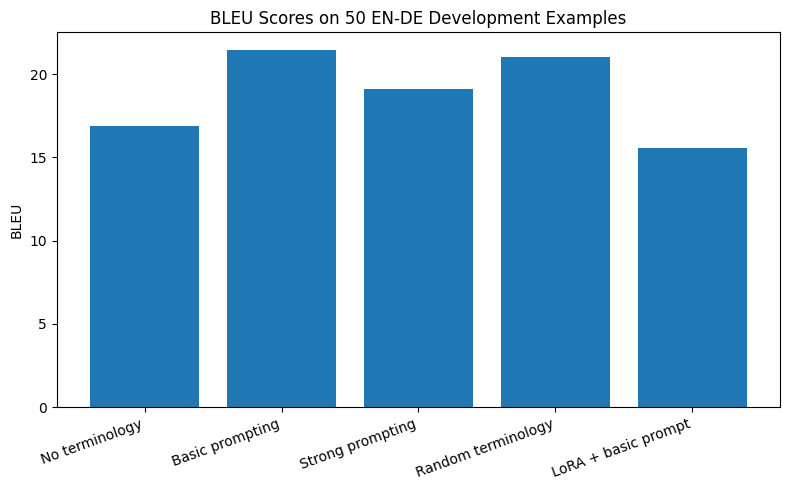

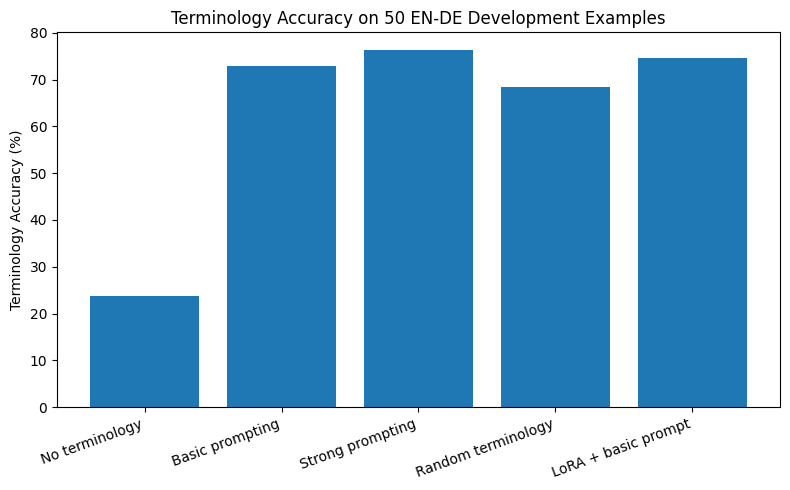

In [61]:
# Separate plots for BLEU and terminology accuracy

methods = verified_metrics_50_df["Method"]
bleu_scores = verified_metrics_50_df["BLEU"]
term_scores = verified_metrics_50_df["Terminology Accuracy"] * 100  # convert to %

# BLEU plot
plt.figure(figsize=(8, 5))
plt.bar(methods, bleu_scores)
plt.xticks(rotation=20, ha="right")
plt.ylabel("BLEU")
plt.title("BLEU Scores on 50 EN-DE Development Examples")
plt.tight_layout()
plt.savefig("bleu_scores_50_verified.png", dpi=300)
plt.show()

# Terminology accuracy plot
plt.figure(figsize=(8, 5))
plt.bar(methods, term_scores)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Terminology Accuracy (%)")
plt.title("Terminology Accuracy on 50 EN-DE Development Examples")
plt.tight_layout()
plt.savefig("term_accuracy_50_verified.png", dpi=300)
plt.show()

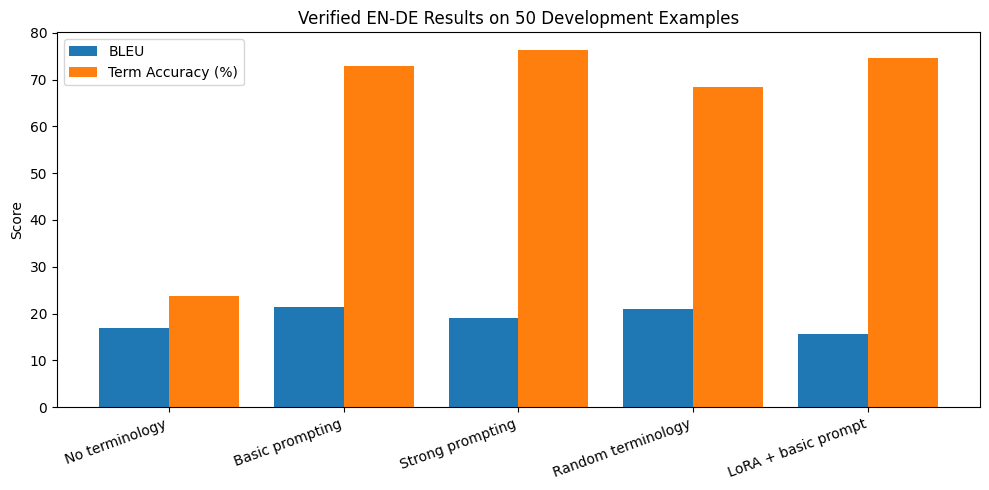

In [62]:
plt.figure(figsize=(10, 5))

x = np.arange(len(verified_metrics_50_df))

plt.bar(x - 0.2, verified_metrics_50_df["BLEU"], width=0.4, label="BLEU")
plt.bar(x + 0.2, verified_metrics_50_df["Terminology Accuracy"] * 100, width=0.4, label="Term Accuracy (%)")

plt.xticks(x, verified_metrics_50_df["Method"], rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Verified EN-DE Results on 50 Development Examples")
plt.legend()
plt.tight_layout()
plt.savefig("verified_results_50_combined.png", dpi=300)
plt.show()

In [63]:
verified_metrics_50_df.to_csv("nlp2_verified_metrics_50.csv", index=False)
verified_outputs_50_df.to_csv("nlp2_verified_outputs_50.csv", index=False)

In [60]:
verified_outputs_50_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_50],
    "reference": references_50,
    "noterm_base": outputs_noterm_50_verified,
    "basic_base": outputs_basic_50_verified,
    "strong_base": outputs_strong_50_verified,
    "random_terms_base": outputs_random_50_verified,
    "lora_basic": outputs_lora_basic_50_verified,
})

verified_outputs_50_df.to_csv("nlp2_verified_outputs_50.csv", index=False)
verified_metrics_50_df.to_csv("nlp2_verified_metrics_50.csv", index=False)

print("Saved verified outputs and metrics.")

Saved verified outputs and metrics.


In [64]:
random_control_df = pd.DataFrame({
    "Evaluation": [
        "Random outputs measured against random terms",
        "Random outputs measured against proper terms"
    ],
    "BLEU": [
        bleu_random_50_verified.score,
        bleu_random_50_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_random_given_50_verified,
        term_acc_random_proper_50_verified
    ]
})

random_control_df

,Evaluation,BLEU,Terminology Accuracy
0,Random outputs measured against random terms,21.03636,0.684211
1,Random outputs measured against proper terms,21.03636,0.254237


## Verified 50-example experiment notes

We evaluate Qwen/Qwen2.5-1.5B-Instruct on 50 English-German development examples from the WMT terminology dataset. We compare no terminology prompting, basic terminology prompting, strong terminology prompting, random terminology prompting, and LoRA + basic prompting.

The first 50-example LoRA run was discarded because the base and LoRA outputs were identical due to the global model variable being overwritten. We fixed this by loading separate `base_model` and `lora_model` objects and passing the model explicitly into the generation function.

Verified results show that basic prompting gives the highest BLEU, while strong prompting gives the highest terminology accuracy. LoRA + basic prompting changes the outputs and maintains high term accuracy, but does not outperform prompt-only methods under the current lightweight training setup.

In [65]:
outputs_lora_noterm_50_verified = generate_translations_with_model(
    eval_noterm_50,
    lora_model,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

In [66]:
bleu_lora_noterm_50_verified = sacrebleu.corpus_bleu(
    outputs_lora_noterm_50_verified,
    [references_50]
)

term_acc_lora_noterm_50_verified = terminology_accuracy(
    outputs_lora_noterm_50_verified,
    eval_proper_50
)

print("LoRA no-term:", bleu_lora_noterm_50_verified.score, term_acc_lora_noterm_50_verified)

LoRA no-term: 15.3023964703802 0.22033898305084745


In [67]:
verified_metrics_50_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Random terminology",
        "LoRA no-term",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_50_verified.score,
        bleu_basic_50_verified.score,
        bleu_strong_50_verified.score,
        bleu_random_50_verified.score,
        bleu_lora_noterm_50_verified.score,
        bleu_lora_basic_50_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_50_verified,
        term_acc_basic_50_verified,
        term_acc_strong_50_verified,
        term_acc_random_given_50_verified,
        term_acc_lora_noterm_50_verified,
        term_acc_lora_basic_50_verified
    ]
})

verified_metrics_50_dfverified_metrics_50_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Random terminology",
        "LoRA no-term",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_50_verified.score,
        bleu_basic_50_verified.score,
        bleu_strong_50_verified.score,
        bleu_random_50_verified.score,
        bleu_lora_noterm_50_verified.score,
        bleu_lora_basic_50_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_50_verified,
        term_acc_basic_50_verified,
        term_acc_strong_50_verified,
        term_acc_random_given_50_verified,
        term_acc_lora_noterm_50_verified,
        term_acc_lora_basic_50_verified
    ]
})

verified_metrics_50_df

,Method,BLEU,Terminology Accuracy
0,No terminology,16.872105,0.237288
1,Basic prompting,21.443679,0.728814
2,Strong prompting,19.104824,0.762712
3,Random terminology,21.036360,0.684211
4,LoRA no-term,15.302396,0.220339
5,LoRA + basic prompt,15.578634,0.745763


In [68]:
verified_metrics_50_df.to_csv("nlp2_verified_metrics_50.csv", index=False)

In [69]:
verified_metrics_50_df.to_csv("nlp2_verified_metrics_50_final.csv", index=False)

In [70]:
plt.savefig("verified_bleu_term_accuracy_50_final.png", dpi=300)

<Figure size 640x480 with 0 Axes>

### Verified 50-example results

These results use separate model objects for the base model and LoRA-adapted model. The earlier unverified LoRA run was discarded because the base and LoRA outputs were identical due to the global model variable being overwritten. In the verified setup, base and LoRA outputs differ, so the results below are used for analysis.

In [71]:
verified_metrics_50_df.to_csv("nlp2_verified_metrics_50_final.csv", index=False)
verified_outputs_50_df.to_csv("nlp2_verified_outputs_50_final.csv", index=False)

In [72]:
qualitative_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_50],
    "reference": references_50,
    "terms": [entry["terms"] for entry in eval_proper_50],
    "no_term": outputs_noterm_50_verified,
    "basic": outputs_basic_50_verified,
    "strong": outputs_strong_50_verified,
    "random_terms": outputs_random_50_verified,
    "lora_no_term": outputs_lora_noterm_50_verified,
    "lora_basic": outputs_lora_basic_50_verified,
})

qualitative_df.to_csv("nlp2_qualitative_outputs_50.csv", index=False)
qualitative_df.head()

,source,reference,terms,no_term,basic,strong,random_terms,lora_no_term,lora_basic
0,This service describes the deployed (run-time)...,Dieser Service beschreibt den implementierten ...,"{'design': 'Entwurf', 'state': 'Zustand'}",Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführt- oder...,Dieses Service beschreibt den ausgeführt- oder...
1,Request a checkup to perform a health diagnost...,"Fordern Sie eine Kontrolle an, um eine Fehlerd...",{'check': 'Kontrolle'},Berechtige einen Nachweis zur Durchführung ein...,"Kontrolliere bitte einen Überwachungsbesuch, u...",Kontrollieren Sie bitte einen Check auf die Du...,"Berechtige einen Überprüfungsbesuch, um eine G...",Gerüste ein Checkup um einen Gesundheitsdiagno...,Kontrollieren Sie Ihre Datenflussanalyse durch...
2,The data product is still available in the pro...,Das Datenprodukt ist weiterhin in der Datenpro...,{'provider': 'Provider'},Der Datenprodukt ist immer noch im Provider-Li...,Der Datenprodukt ist noch im Angebot des Provi...,Der Datenprodukt ist immer noch im Liste der D...,Der Datenprodukt ist noch im Angebot des Verle...,Der Datenprodukt ist noch im Provider-Liste ve...,Der Datenprodukt ist noch im Provider-Liste ve...
3,This availability match percentage is calculat...,Diese prozentuale Verfügbarkeitsübereinstimmun...,{'percentage': 'prozentual'},Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeitsübereinstimmung ist basier...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Dieses Verfügbarkeitsmatch-Prozentsatz wird au...
4,Open the consumption model containing the meas...,Öffnen Sie das Verbrauchsmodell mit den Kennza...,{'consumption model': 'Verbrauchsmodell'},"Öffne die Konsummodell-Ab塑e, die die Maßnahmen...","Öffne das Verbrauchsmodell, das die Maßnahmen ...","Verwenden Sie den Verbrauchsmodell, der die Ma...","Öffne die Konsummodell-Abfrage, die die Maßnah...",Öffnen Sie den Konsummodellinhalt mit den Maße...,Gerne! Hier ist die deutsche Übersetzung:\n\nÖ...


In [73]:
qualitative_df.to_csv("nlp2_qualitative_outputs_50.csv", index=False)

In [74]:
# 100-example verified evaluation setup

N_EVAL_100 = 100

eval_noterm_100 = ende_noterm[:N_EVAL_100]
eval_proper_100 = ende_proper[:N_EVAL_100]
eval_random_100 = ende_random[:N_EVAL_100]

references_100 = [
    entry["de"].strip()
    for entry in eval_proper_100
]

print("Evaluation size:", N_EVAL_100)

Evaluation size: 100


In [75]:
# Generate base model outputs for 100 examples

outputs_noterm_100_verified = generate_translations_with_model(
    eval_noterm_100,
    base_model,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

outputs_basic_100_verified = generate_translations_with_model(
    eval_proper_100,
    base_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

outputs_strong_100_verified = generate_translations_with_model(
    eval_proper_100,
    base_model,
    prompt_type="strong",
    batch_size=2,
    max_new_tokens=160
)

outputs_random_100_verified = generate_translations_with_model(
    eval_random_100,
    base_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [76]:
# Generate LoRA outputs for 100 examples

lora_model = trainer.model
lora_model.eval()

outputs_lora_noterm_100_verified = generate_translations_with_model(
    eval_noterm_100,
    lora_model,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

outputs_lora_basic_100_verified = generate_translations_with_model(
    eval_proper_100,
    lora_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [77]:
# Verified metrics for 100 examples

bleu_noterm_100_verified = sacrebleu.corpus_bleu(outputs_noterm_100_verified, [references_100])
bleu_basic_100_verified = sacrebleu.corpus_bleu(outputs_basic_100_verified, [references_100])
bleu_strong_100_verified = sacrebleu.corpus_bleu(outputs_strong_100_verified, [references_100])
bleu_random_100_verified = sacrebleu.corpus_bleu(outputs_random_100_verified, [references_100])
bleu_lora_noterm_100_verified = sacrebleu.corpus_bleu(outputs_lora_noterm_100_verified, [references_100])
bleu_lora_basic_100_verified = sacrebleu.corpus_bleu(outputs_lora_basic_100_verified, [references_100])

term_acc_noterm_100_verified = terminology_accuracy(outputs_noterm_100_verified, eval_proper_100)
term_acc_basic_100_verified = terminology_accuracy(outputs_basic_100_verified, eval_proper_100)
term_acc_strong_100_verified = terminology_accuracy(outputs_strong_100_verified, eval_proper_100)

term_acc_random_given_100_verified = terminology_accuracy(outputs_random_100_verified, eval_random_100)
term_acc_random_proper_100_verified = terminology_accuracy(outputs_random_100_verified, eval_proper_100)

term_acc_lora_noterm_100_verified = terminology_accuracy(outputs_lora_noterm_100_verified, eval_proper_100)
term_acc_lora_basic_100_verified = terminology_accuracy(outputs_lora_basic_100_verified, eval_proper_100)

print("VERIFIED 100-example results")
print("No terminology:", bleu_noterm_100_verified.score, term_acc_noterm_100_verified)
print("Basic prompting:", bleu_basic_100_verified.score, term_acc_basic_100_verified)
print("Strong prompting:", bleu_strong_100_verified.score, term_acc_strong_100_verified)
print("Random terminology, adherence to random terms:", bleu_random_100_verified.score, term_acc_random_given_100_verified)
print("Random terminology, adherence to proper terms:", bleu_random_100_verified.score, term_acc_random_proper_100_verified)
print("LoRA no-term:", bleu_lora_noterm_100_verified.score, term_acc_lora_noterm_100_verified)
print("LoRA + basic prompt:", bleu_lora_basic_100_verified.score, term_acc_lora_basic_100_verified)

VERIFIED 100-example results
No terminology: 18.682698669962623 0.27586206896551724
Basic prompting: 20.86073515236053 0.6982758620689655
Strong prompting: 18.826400062788792 0.6810344827586207
Random terminology, adherence to random terms: 22.6063981935756 0.7191780821917808
Random terminology, adherence to proper terms: 22.6063981935756 0.2672413793103448
LoRA no-term: 15.781687865882128 0.22413793103448276
LoRA + basic prompt: 16.494620723900947 0.7327586206896551


In [78]:
verified_metrics_100_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Random terminology",
        "LoRA no-term",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_100_verified.score,
        bleu_basic_100_verified.score,
        bleu_strong_100_verified.score,
        bleu_random_100_verified.score,
        bleu_lora_noterm_100_verified.score,
        bleu_lora_basic_100_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_100_verified,
        term_acc_basic_100_verified,
        term_acc_strong_100_verified,
        term_acc_random_given_100_verified,
        term_acc_lora_noterm_100_verified,
        term_acc_lora_basic_100_verified
    ]
})

verified_outputs_100_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_100],
    "reference": references_100,
    "terms": [entry["terms"] for entry in eval_proper_100],
    "noterm_base": outputs_noterm_100_verified,
    "basic_base": outputs_basic_100_verified,
    "strong_base": outputs_strong_100_verified,
    "random_terms_base": outputs_random_100_verified,
    "lora_no_term": outputs_lora_noterm_100_verified,
    "lora_basic": outputs_lora_basic_100_verified,
})

verified_metrics_100_df.to_csv("nlp2_verified_metrics_100.csv", index=False)
verified_outputs_100_df.to_csv("nlp2_verified_outputs_100.csv", index=False)

verified_metrics_100_df

,Method,BLEU,Terminology Accuracy
0,No terminology,18.682699,0.275862
1,Basic prompting,20.860735,0.698276
2,Strong prompting,18.826400,0.681034
3,Random terminology,22.606398,0.719178
4,LoRA no-term,15.781688,0.224138
5,LoRA + basic prompt,16.494621,0.732759


In [79]:
verified_metrics_100_df.to_csv("nlp2_verified_metrics_100_final.csv", index=False)
verified_outputs_100_df.to_csv("nlp2_verified_outputs_100_final.csv", index=False)

In [81]:
outputs_fewshot_100_verified = generate_fewshot(
    eval_proper_100,
    batch_size=2
)

In [82]:
bleu_fewshot_100_verified = sacrebleu.corpus_bleu(
    outputs_fewshot_100_verified,
    [references_100]
)

term_acc_fewshot_100_verified = terminology_accuracy(
    outputs_fewshot_100_verified,
    eval_proper_100
)

print("Few-shot prompting:", bleu_fewshot_100_verified.score, term_acc_fewshot_100_verified)

Few-shot prompting: 14.154002006264031 0.5603448275862069


In [83]:
verified_metrics_100_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Few-shot prompting",
        "Random terminology",
        "LoRA no-term",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_100_verified.score,
        bleu_basic_100_verified.score,
        bleu_strong_100_verified.score,
        bleu_fewshot_100_verified.score,
        bleu_random_100_verified.score,
        bleu_lora_noterm_100_verified.score,
        bleu_lora_basic_100_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_100_verified,
        term_acc_basic_100_verified,
        term_acc_strong_100_verified,
        term_acc_fewshot_100_verified,
        term_acc_random_given_100_verified,
        term_acc_lora_noterm_100_verified,
        term_acc_lora_basic_100_verified
    ]
})

verified_metrics_100_df.to_csv("nlp2_verified_metrics_100_final.csv", index=False)
verified_metrics_100_df

,Method,BLEU,Terminology Accuracy
0,No terminology,18.682699,0.275862
1,Basic prompting,20.860735,0.698276
2,Strong prompting,18.826400,0.681034
3,Few-shot prompting,14.154002,0.560345
4,Random terminology,22.606398,0.719178
5,LoRA no-term,15.781688,0.224138
6,LoRA + basic prompt,16.494621,0.732759


In [84]:
verified_metrics_100_df.to_csv("nlp2_verified_metrics_100_final.csv", index=False)

verified_outputs_100_df["fewshot"] = outputs_fewshot_100_verified
verified_outputs_100_df.to_csv("nlp2_verified_outputs_100_final.csv", index=False)

print("Saved final 100-example metrics and outputs.")

Saved final 100-example metrics and outputs.


In [85]:
verified_metrics_100_df.to_csv("nlp2_verified_metrics_100_final.csv", index=False)

verified_outputs_100_df["fewshot"] = outputs_fewshot_100_verified
verified_outputs_100_df.to_csv("nlp2_verified_outputs_100_final.csv", index=False)

print("Saved final 100-example metrics and outputs.")

Saved final 100-example metrics and outputs.


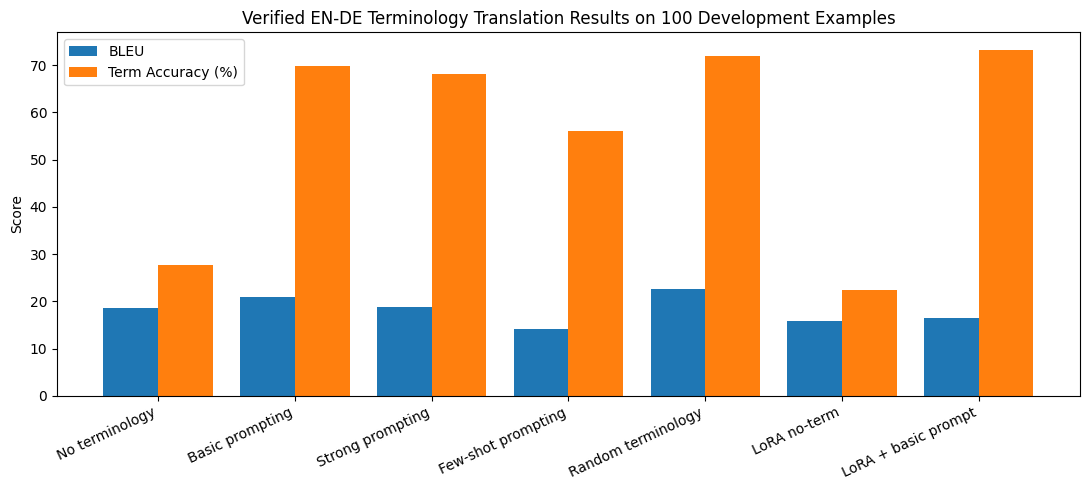

In [86]:
plt.figure(figsize=(11, 5))

x = np.arange(len(verified_metrics_100_df))

plt.bar(x - 0.2, verified_metrics_100_df["BLEU"], width=0.4, label="BLEU")
plt.bar(x + 0.2, verified_metrics_100_df["Terminology Accuracy"] * 100, width=0.4, label="Term Accuracy (%)")

plt.xticks(x, verified_metrics_100_df["Method"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("Verified EN-DE Terminology Translation Results on 100 Development Examples")
plt.legend()
plt.tight_layout()

plt.savefig("verified_results_100_combined.png", dpi=300)
plt.show()

In [87]:
qualitative_100_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_100],
    "reference": references_100,
    "terms": [entry["terms"] for entry in eval_proper_100],
    "no_term": outputs_noterm_100_verified,
    "basic": outputs_basic_100_verified,
    "strong": outputs_strong_100_verified,
    "fewshot": outputs_fewshot_100_verified,
    "random_terms": outputs_random_100_verified,
    "lora_no_term": outputs_lora_noterm_100_verified,
    "lora_basic": outputs_lora_basic_100_verified,
})

qualitative_100_df.to_csv("nlp2_qualitative_outputs_100.csv", index=False)
qualitative_100_df.head()

,source,reference,terms,no_term,basic,strong,fewshot,random_terms,lora_no_term,lora_basic
0,This service describes the deployed (run-time)...,Dieser Service beschreibt den implementierten ...,"{'design': 'Entwurf', 'state': 'Zustand'}",Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt die ausgeführte (bet...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführt- oder...,Dieses Service beschreibt den ausgeführt- oder...
1,Request a checkup to perform a health diagnost...,"Fordern Sie eine Kontrolle an, um eine Fehlerd...",{'check': 'Kontrolle'},Berechtige einen Nachweis zur Durchführung ein...,"Kontrolliere bitte einen Überwachungsbesuch, u...",Kontrollieren Sie bitte einen Check auf die Du...,"Anfordern Sie eine Kontrollklausur, um einen G...","Berechtige einen Überprüfungsbesuch, um eine G...",Gerüste ein Checkup um einen Gesundheitsdiagno...,Kontrollieren Sie Ihre Datenflussanalyse durch...
2,The data product is still available in the pro...,Das Datenprodukt ist weiterhin in der Datenpro...,{'provider': 'Provider'},Der Datenprodukt ist immer noch im Provider-Li...,Der Datenprodukt ist noch im Angebot des Provi...,Der Datenprodukt ist immer noch im Liste der D...,The data product is still available in the pro...,Der Datenprodukt ist noch im Angebot des Verle...,Der Datenprodukt ist noch im Provider-Liste ve...,Der Datenprodukt ist noch im Provider-Liste ve...
3,This availability match percentage is calculat...,Diese prozentuale Verfügbarkeitsübereinstimmun...,{'percentage': 'prozentual'},Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeitsübereinstimmung ist basier...,This availability match percentage is calculat...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Dieses Verfügbarkeitsmatch-Prozentsatz wird au...
4,Open the consumption model containing the meas...,Öffnen Sie das Verbrauchsmodell mit den Kennza...,{'consumption model': 'Verbrauchsmodell'},"Öffne die Konsummodell-Ab塑e, die die Maßnahmen...","Öffne das Verbrauchsmodell, das die Maßnahmen ...","Verwenden Sie den Verbrauchsmodell, der die Ma...",Openen Sie das Verbrauchsmodell mit den Maßen ...,"Öffne die Konsummodell-Abfrage, die die Maßnah...",Öffnen Sie den Konsummodellinhalt mit den Maße...,Gerne! Hier ist die deutsche Übersetzung:\n\nÖ...


In [88]:
# 500-example verified evaluation setup

N_EVAL_500 = 500

eval_noterm_500 = ende_noterm[:N_EVAL_500]
eval_proper_500 = ende_proper[:N_EVAL_500]
eval_random_500 = ende_random[:N_EVAL_500]

references_500 = [
    entry["de"].strip()
    for entry in eval_proper_500
]

print("Evaluation size:", N_EVAL_500)

Evaluation size: 500


In [89]:
outputs_noterm_500_verified = generate_translations_with_model(
    eval_noterm_500,
    base_model,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

outputs_basic_500_verified = generate_translations_with_model(
    eval_proper_500,
    base_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

outputs_strong_500_verified = generate_translations_with_model(
    eval_proper_500,
    base_model,
    prompt_type="strong",
    batch_size=2,
    max_new_tokens=160
)

outputs_random_500_verified = generate_translations_with_model(
    eval_random_500,
    base_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [90]:
base_outputs_500_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_500],
    "reference": references_500,
    "terms": [entry["terms"] for entry in eval_proper_500],
    "noterm_base": outputs_noterm_500_verified,
    "basic_base": outputs_basic_500_verified,
    "strong_base": outputs_strong_500_verified,
    "random_terms_base": outputs_random_500_verified,
})

base_outputs_500_df.to_csv("nlp2_base_outputs_500.csv", index=False)
print("Saved base 500 outputs.")

Saved base 500 outputs.


In [91]:
bleu_noterm_500_verified = sacrebleu.corpus_bleu(outputs_noterm_500_verified, [references_500])
bleu_basic_500_verified = sacrebleu.corpus_bleu(outputs_basic_500_verified, [references_500])
bleu_strong_500_verified = sacrebleu.corpus_bleu(outputs_strong_500_verified, [references_500])
bleu_random_500_verified = sacrebleu.corpus_bleu(outputs_random_500_verified, [references_500])

term_acc_noterm_500_verified = terminology_accuracy(outputs_noterm_500_verified, eval_proper_500)
term_acc_basic_500_verified = terminology_accuracy(outputs_basic_500_verified, eval_proper_500)
term_acc_strong_500_verified = terminology_accuracy(outputs_strong_500_verified, eval_proper_500)

term_acc_random_given_500_verified = terminology_accuracy(outputs_random_500_verified, eval_random_500)
term_acc_random_proper_500_verified = terminology_accuracy(outputs_random_500_verified, eval_proper_500)

print("VERIFIED 500-example base results")
print("No terminology:", bleu_noterm_500_verified.score, term_acc_noterm_500_verified)
print("Basic prompting:", bleu_basic_500_verified.score, term_acc_basic_500_verified)
print("Strong prompting:", bleu_strong_500_verified.score, term_acc_strong_500_verified)
print("Random terminology, adherence to random terms:", bleu_random_500_verified.score, term_acc_random_given_500_verified)
print("Random terminology, adherence to proper terms:", bleu_random_500_verified.score, term_acc_random_proper_500_verified)

VERIFIED 500-example base results
No terminology: 19.83136420048834 0.2621184919210054
Basic prompting: 21.629986236948735 0.7001795332136446
Strong prompting: 17.91042352117265 0.7414721723518851
Random terminology, adherence to random terms: 21.276542701763468 0.7464114832535885
Random terminology, adherence to proper terms: 21.276542701763468 0.296229802513465


In [92]:
# Generate LoRA + basic prompt outputs for 500 examples

lora_model = trainer.model
lora_model.eval()

outputs_lora_basic_500_verified = generate_translations_with_model(
    eval_proper_500,
    lora_model,
    prompt_type="basic",
    batch_size=2,
    max_new_tokens=160
)

In [93]:
# Save LoRA + basic 500 outputs

lora_basic_500_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_500],
    "reference": references_500,
    "terms": [entry["terms"] for entry in eval_proper_500],
    "lora_basic": outputs_lora_basic_500_verified,
})

lora_basic_500_df.to_csv("nlp2_lora_basic_outputs_500.csv", index=False)

print("Saved LoRA + basic 500 outputs.")

Saved LoRA + basic 500 outputs.


In [94]:
# Compute LoRA + basic 500 metrics

bleu_lora_basic_500_verified = sacrebleu.corpus_bleu(
    outputs_lora_basic_500_verified,
    [references_500]
)

term_acc_lora_basic_500_verified = terminology_accuracy(
    outputs_lora_basic_500_verified,
    eval_proper_500
)

print("LoRA + basic prompt 500:")
print("BLEU:", bleu_lora_basic_500_verified.score)
print("Terminology accuracy:", term_acc_lora_basic_500_verified)

LoRA + basic prompt 500:
BLEU: 12.455549108615365
Terminology accuracy: 0.6283662477558348


In [95]:
# Generate LoRA no-term outputs for 500 examples

outputs_lora_noterm_500_verified = generate_translations_with_model(
    eval_noterm_500,
    lora_model,
    prompt_type="noterm",
    batch_size=2,
    max_new_tokens=160
)

In [96]:
bleu_lora_noterm_500_verified = sacrebleu.corpus_bleu(
    outputs_lora_noterm_500_verified,
    [references_500]
)

term_acc_lora_noterm_500_verified = terminology_accuracy(
    outputs_lora_noterm_500_verified,
    eval_proper_500
)

print("LoRA no-term 500:")
print("BLEU:", bleu_lora_noterm_500_verified.score)
print("Terminology accuracy:", term_acc_lora_noterm_500_verified)

LoRA no-term 500:
BLEU: 11.472782400658746
Terminology accuracy: 0.18850987432675045


In [97]:
verified_metrics_500_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Random terminology",
        "LoRA no-term",
        "LoRA + basic prompt"
    ],
    "BLEU": [
        bleu_noterm_500_verified.score,
        bleu_basic_500_verified.score,
        bleu_strong_500_verified.score,
        bleu_random_500_verified.score,
        bleu_lora_noterm_500_verified.score,
        bleu_lora_basic_500_verified.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_500_verified,
        term_acc_basic_500_verified,
        term_acc_strong_500_verified,
        term_acc_random_given_500_verified,
        term_acc_lora_noterm_500_verified,
        term_acc_lora_basic_500_verified
    ]
})

verified_metrics_500_df.to_csv("nlp2_verified_metrics_500_final.csv", index=False)
verified_metrics_500_df

,Method,BLEU,Terminology Accuracy
0,No terminology,19.831364,0.262118
1,Basic prompting,21.629986,0.700180
2,Strong prompting,17.910424,0.741472
3,Random terminology,21.276543,0.746411
4,LoRA no-term,11.472782,0.188510
5,LoRA + basic prompt,12.455549,0.628366


In [98]:
# Inspect LoRA outputs compared with base prompting outputs

lora_inspection_500_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_500],
    "reference": references_500,
    "terms": [entry["terms"] for entry in eval_proper_500],
    "base_basic": outputs_basic_500_verified,
    "base_strong": outputs_strong_500_verified,
    "lora_no_term": outputs_lora_noterm_500_verified,
    "lora_basic": outputs_lora_basic_500_verified,
})

lora_inspection_500_df.to_csv("nlp2_lora_inspection_500.csv", index=False)

lora_inspection_500_df.head(10)

,source,reference,terms,base_basic,base_strong,lora_no_term,lora_basic
0,This service describes the deployed (run-time)...,Dieser Service beschreibt den implementierten ...,"{'design': 'Entwurf', 'state': 'Zustand'}",Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführten (be...,Dieses Service beschreibt den ausgeführt- oder...,Dieses Service beschreibt den ausgeführt- oder...
1,Request a checkup to perform a health diagnost...,"Fordern Sie eine Kontrolle an, um eine Fehlerd...",{'check': 'Kontrolle'},"Kontrolliere bitte einen Überwachungsbesuch, u...",Kontrollieren Sie bitte einen Check auf die Du...,Gerüste ein Checkup um einen Gesundheitsdiagno...,Kontrollieren Sie Ihre Datenflussanalyse durch...
2,The data product is still available in the pro...,Das Datenprodukt ist weiterhin in der Datenpro...,{'provider': 'Provider'},Der Datenprodukt ist noch im Angebot des Provi...,Der Datenprodukt ist immer noch im Liste der D...,Der Datenprodukt ist noch im Provider-Liste ve...,Der Datenprodukt ist noch im Provider-Liste ve...
3,This availability match percentage is calculat...,Diese prozentuale Verfügbarkeitsübereinstimmun...,{'percentage': 'prozentual'},Diese Verfügbarkeits-Match-Prozentsatz wird au...,Diese Verfügbarkeitsübereinstimmung ist basier...,Diese Verfügbarkeits-Match-Prozentsatz wird au...,Dieses Verfügbarkeitsmatch-Prozentsatz wird au...
4,Open the consumption model containing the meas...,Öffnen Sie das Verbrauchsmodell mit den Kennza...,{'consumption model': 'Verbrauchsmodell'},"Öffne das Verbrauchsmodell, das die Maßnahmen ...","Verwenden Sie den Verbrauchsmodell, der die Ma...",Öffnen Sie den Konsummodellinhalt mit den Maße...,Gerne! Hier ist die deutsche Übersetzung:\n\nÖ...
5,"Under Manually Delete Task Log , you determine...",Unter Aufgabenprotokoll manuell löschen legen ...,{'task log': 'Aufgabenprotokoll'},"Auf der Schaltfläche ""Manuell Entfernen von Au...",Aufforderung zum Entfernen des Aufgabenprotoko...,Gerne! Bitte geben Sie den englischen Text ein...,Gerne! Hier ist die deutsche Übersetzung:\n\nD...
6,It might make sense to hibernate this space as...,"Es ist ggf. sinnvoll, diesen Space in den Ruhe...",{'space': 'Space'},"Es könnte Sinn machen, dieses Space zu Hiberna...","Es könnte Sinn machen, dieses Space zu Hiberna...","Es könnte Sinn machen, diesen Raum in den Hibe...","Gerne würde ich es als sinnvoll ansehen, diese..."
7,The context will be available as additional in...,Der Kontext steht als zusätzliche Information ...,{'consumption model': 'Verbrauchsmodell'},Der Kontext wird bei jeder Nutzung der Verbind...,Der Kontext wird bei jeder Verwendung der Bezi...,Die Kontextinformation wird als zusätzliche In...,Verwendungsbereich wird als zusätzliche Inform...
8,"Special categories of personal data, such as d...","Besondere Kategorien personenbezogener Daten, ...",{'membership': 'Zugehörigkeit'},"Spezifische Kategorien persönlicher Daten, wie...","Sonderklassen persönlicher Daten, wie beispiel...",Specialer Datenaustausch über Persönliche Date...,Zusätzliche Kategorien personenbezogener Daten...
9,Choose your data provider profile you want to ...,"Wählen Sie Ihr Datenproviderprofil aus, in dem...",{'data provider': 'Datenprovider'},Wählen Sie Ihren gewünschten Profil für den Da...,"Datenproviderprofil auswählen, den Sie arbeite...","Wählen Sie Ihren Datenverwalterprofile aus, de...","Wählen Sie Ihren Datenprovider-Profil aus, den..."


In [99]:
# Check for common chat-style boilerplate in LoRA outputs

boilerplate_patterns = [
    "Gerne",
    "Hier ist",
    "Übersetzung",
    "deutsche Übersetzung",
    "Die deutsche Übersetzung",
    "Translation"
]

for pattern in boilerplate_patterns:
    count = sum(pattern.lower() in output.lower() for output in outputs_lora_basic_500_verified)
    print(pattern, ":", count)

Gerne : 156
Hier ist : 95
Übersetzung : 105
deutsche Übersetzung : 96
Die deutsche Übersetzung : 96
Translation : 0


In [100]:
def clean_translation_output(text):
    cleaned = text.strip()

    prefixes = [
        "Gerne! Hier ist die deutsche Übersetzung:",
        "Gerne, hier ist die deutsche Übersetzung:",
        "Gerne hier ist die deutsche Übersetzung:",
        "Hier ist die deutsche Übersetzung:",
        "Die deutsche Übersetzung lautet:",
        "Die deutsche Übersetzung ist:",
        "Deutsche Übersetzung:",
        "Übersetzung:",
        "German translation:",
        "Translation:",
    ]

    for prefix in prefixes:
        if cleaned.lower().startswith(prefix.lower()):
            cleaned = cleaned[len(prefix):].strip()

    return cleaned

In [101]:
outputs_lora_basic_500_cleaned = [
    clean_translation_output(output)
    for output in outputs_lora_basic_500_verified
]

In [102]:
changed_count = 0

for original, cleaned in zip(outputs_lora_basic_500_verified, outputs_lora_basic_500_cleaned):
    if original != cleaned:
        changed_count += 1

print("Number of outputs changed by cleanup:", changed_count)

Number of outputs changed by cleanup: 95


In [103]:
bleu_lora_basic_500_cleaned = sacrebleu.corpus_bleu(
    outputs_lora_basic_500_cleaned,
    [references_500]
)

term_acc_lora_basic_500_cleaned = terminology_accuracy(
    outputs_lora_basic_500_cleaned,
    eval_proper_500
)

print("Original LoRA + basic 500:")
print("BLEU:", bleu_lora_basic_500_verified.score)
print("Terminology accuracy:", term_acc_lora_basic_500_verified)

print("\nCleaned LoRA + basic 500:")
print("BLEU:", bleu_lora_basic_500_cleaned.score)
print("Terminology accuracy:", term_acc_lora_basic_500_cleaned)

Original LoRA + basic 500:
BLEU: 12.455549108615365
Terminology accuracy: 0.6283662477558348

Cleaned LoRA + basic 500:
BLEU: 14.16859771233233
Terminology accuracy: 0.6265709156193896


In [104]:
cleaned_lora_500_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_500],
    "reference": references_500,
    "terms": [entry["terms"] for entry in eval_proper_500],
    "lora_basic_original": outputs_lora_basic_500_verified,
    "lora_basic_cleaned": outputs_lora_basic_500_cleaned,
})

cleaned_lora_500_df.to_csv("nlp2_lora_basic_cleaned_outputs_500.csv", index=False)

print("Saved cleaned LoRA outputs.")

Saved cleaned LoRA outputs.


In [105]:
final_metrics_500_df = pd.DataFrame({
    "Method": [
        "No terminology",
        "Basic prompting",
        "Strong prompting",
        "Random terminology",
        "LoRA no-term",
        "LoRA + basic prompt",
        "LoRA + basic prompt + cleanup"
    ],
    "BLEU": [
        bleu_noterm_500_verified.score,
        bleu_basic_500_verified.score,
        bleu_strong_500_verified.score,
        bleu_random_500_verified.score,
        bleu_lora_noterm_500_verified.score,
        bleu_lora_basic_500_verified.score,
        bleu_lora_basic_500_cleaned.score
    ],
    "Terminology Accuracy": [
        term_acc_noterm_500_verified,
        term_acc_basic_500_verified,
        term_acc_strong_500_verified,
        term_acc_random_given_500_verified,
        term_acc_lora_noterm_500_verified,
        term_acc_lora_basic_500_verified,
        term_acc_lora_basic_500_cleaned
    ],
    "Notes": [
        "proper terms",
        "proper terms",
        "proper terms",
        f"random-term adherence; proper-term adherence = {term_acc_random_proper_500_verified:.3f}",
        "proper terms",
        "proper terms",
        "proper terms; cleaned boilerplate"
    ]
})

final_metrics_500_df.to_csv("nlp2_final_metrics_500.csv", index=False)

final_metrics_500_df

,Method,BLEU,Terminology Accuracy,Notes
0,No terminology,19.831364,0.262118,proper terms
1,Basic prompting,21.629986,0.700180,proper terms
2,Strong prompting,17.910424,0.741472,proper terms
3,Random terminology,21.276543,0.746411,random-term adherence; proper-term adherence =...
4,LoRA no-term,11.472782,0.188510,proper terms
5,LoRA + basic prompt,12.455549,0.628366,proper terms
6,LoRA + basic prompt + cleanup,14.168598,0.626571,proper terms; cleaned boilerplate


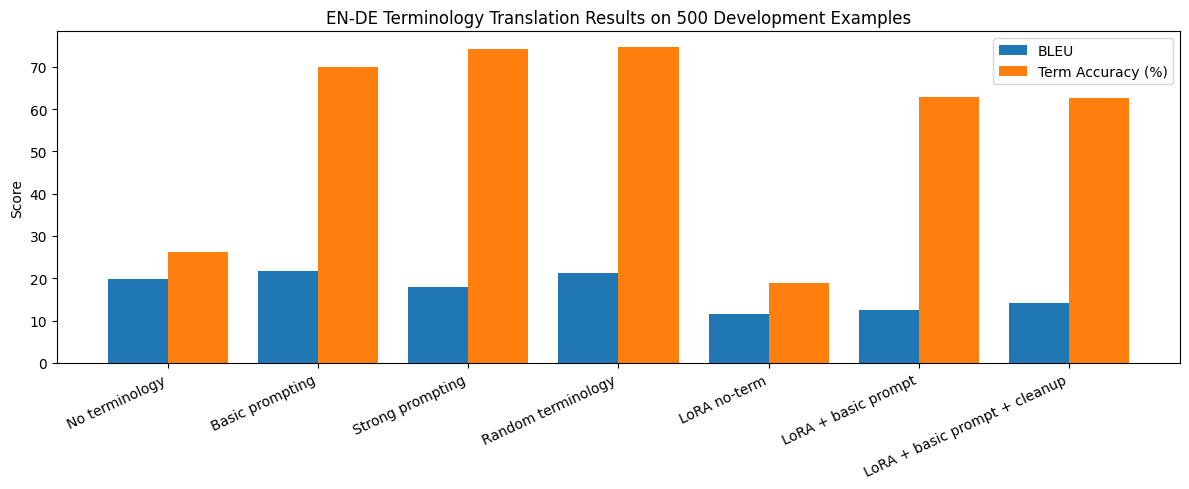

In [106]:
plt.figure(figsize=(12, 5))

x = np.arange(len(final_metrics_500_df))

plt.bar(x - 0.2, final_metrics_500_df["BLEU"], width=0.4, label="BLEU")
plt.bar(x + 0.2, final_metrics_500_df["Terminology Accuracy"] * 100, width=0.4, label="Term Accuracy (%)")

plt.xticks(x, final_metrics_500_df["Method"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("EN-DE Terminology Translation Results on 500 Development Examples")
plt.legend()
plt.tight_layout()

plt.savefig("nlp2_final_results_500.png", dpi=300, bbox_inches="tight")
plt.show()

In [107]:
final_qualitative_500_df = pd.DataFrame({
    "source": [entry["en"].strip() for entry in eval_proper_500],
    "reference": references_500,
    "terms": [entry["terms"] for entry in eval_proper_500],
    "base_basic": outputs_basic_500_verified,
    "base_strong": outputs_strong_500_verified,
    "lora_no_term": outputs_lora_noterm_500_verified,
    "lora_basic": outputs_lora_basic_500_verified,
    "lora_basic_cleaned": outputs_lora_basic_500_cleaned,
})

final_qualitative_500_df.to_csv("nlp2_final_qualitative_outputs_500.csv", index=False)

print("Saved final qualitative outputs.")

Saved final qualitative outputs.


In [108]:
outputs_basic_500_cleaned = [
    clean_translation_output(output)
    for output in outputs_basic_500_verified
]

outputs_strong_500_cleaned = [
    clean_translation_output(output)
    for output in outputs_strong_500_verified
]

bleu_basic_500_cleaned = sacrebleu.corpus_bleu(outputs_basic_500_cleaned, [references_500])
bleu_strong_500_cleaned = sacrebleu.corpus_bleu(outputs_strong_500_cleaned, [references_500])

term_acc_basic_500_cleaned = terminology_accuracy(outputs_basic_500_cleaned, eval_proper_500)
term_acc_strong_500_cleaned = terminology_accuracy(outputs_strong_500_cleaned, eval_proper_500)

print("Basic original:", bleu_basic_500_verified.score, term_acc_basic_500_verified)
print("Basic cleaned:", bleu_basic_500_cleaned.score, term_acc_basic_500_cleaned)

print("Strong original:", bleu_strong_500_verified.score, term_acc_strong_500_verified)
print("Strong cleaned:", bleu_strong_500_cleaned.score, term_acc_strong_500_cleaned)

Basic original: 21.629986236948735 0.7001795332136446
Basic cleaned: 21.632839330679808 0.7001795332136446
Strong original: 17.91042352117265 0.7414721723518851
Strong cleaned: 17.91042352117265 0.7414721723518851


In [109]:
basic_changed = sum(
    original != cleaned
    for original, cleaned in zip(outputs_basic_500_verified, outputs_basic_500_cleaned)
)

strong_changed = sum(
    original != cleaned
    for original, cleaned in zip(outputs_strong_500_verified, outputs_strong_500_cleaned)
)

print("Basic outputs changed:", basic_changed)
print("Strong outputs changed:", strong_changed)

Basic outputs changed: 1
Strong outputs changed: 0


In [110]:
cleanup_check_df = pd.DataFrame({
    "Method": [
        "Basic prompting",
        "Strong prompting",
        "LoRA + basic prompt"
    ],
    "Changed outputs": [
        basic_changed,
        strong_changed,
        changed_count
    ],
    "Original BLEU": [
        bleu_basic_500_verified.score,
        bleu_strong_500_verified.score,
        bleu_lora_basic_500_verified.score
    ],
    "Cleaned BLEU": [
        bleu_basic_500_cleaned.score,
        bleu_strong_500_cleaned.score,
        bleu_lora_basic_500_cleaned.score
    ],
    "Original Term Accuracy": [
        term_acc_basic_500_verified,
        term_acc_strong_500_verified,
        term_acc_lora_basic_500_verified
    ],
    "Cleaned Term Accuracy": [
        term_acc_basic_500_cleaned,
        term_acc_strong_500_cleaned,
        term_acc_lora_basic_500_cleaned
    ]
})

cleanup_check_df.to_csv("nlp2_cleanup_check_500.csv", index=False)
cleanup_check_df

,Method,Changed outputs,Original BLEU,Cleaned BLEU,Original Term Accuracy,Cleaned Term Accuracy
0,Basic prompting,1,21.629986,21.632839,0.700180,0.700180
1,Strong prompting,0,17.910424,17.910424,0.741472,0.741472
2,LoRA + basic prompt,95,12.455549,14.168598,0.628366,0.626571


In [111]:
# Final save cell

# 1. Save final 500 metrics
final_metrics_500_df.to_csv("nlp2_final_metrics_500.csv", index=False)

# 2. Save final qualitative outputs
final_qualitative_500_df.to_csv("nlp2_final_qualitative_outputs_500.csv", index=False)

# 3. Save LoRA cleaned outputs
cleaned_lora_500_df.to_csv("nlp2_lora_basic_cleaned_outputs_500.csv", index=False)

# 4. Save cleanup comparison
cleanup_check_df.to_csv("nlp2_cleanup_check_500.csv", index=False)

# 5. Save 100-example full comparison too, because it includes few-shot
verified_metrics_100_df.to_csv("nlp2_verified_metrics_100_final.csv", index=False)
verified_outputs_100_df.to_csv("nlp2_verified_outputs_100_final.csv", index=False)

print("All important CSV files saved.")

All important CSV files saved.


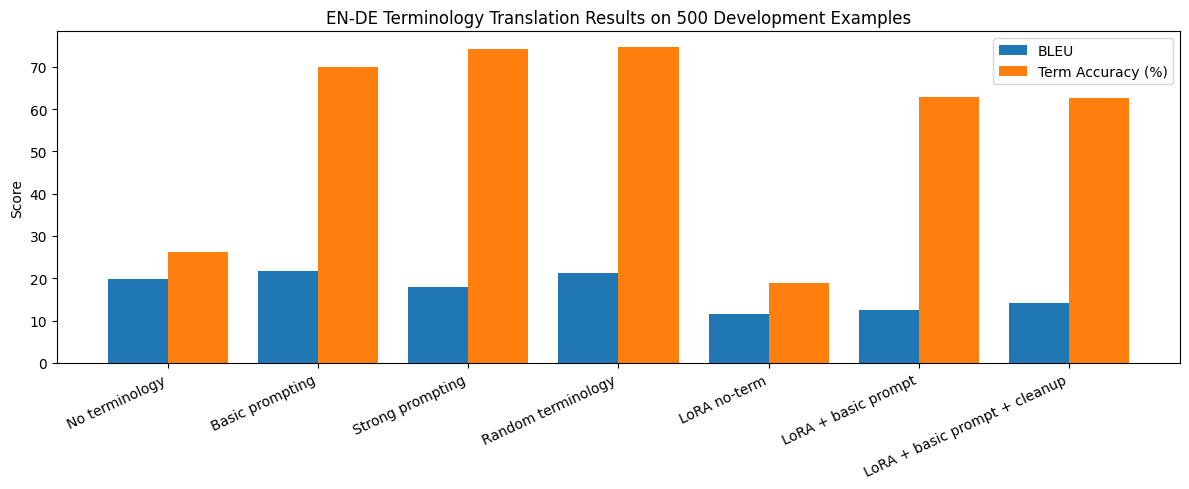

Graph saved.


In [112]:
plt.figure(figsize=(12, 5))

x = np.arange(len(final_metrics_500_df))

plt.bar(x - 0.2, final_metrics_500_df["BLEU"], width=0.4, label="BLEU")
plt.bar(x + 0.2, final_metrics_500_df["Terminology Accuracy"] * 100, width=0.4, label="Term Accuracy (%)")

plt.xticks(x, final_metrics_500_df["Method"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("EN-DE Terminology Translation Results on 500 Development Examples")
plt.legend()
plt.tight_layout()

plt.savefig("nlp2_final_results_500.png", dpi=300, bbox_inches="tight")
plt.show()

print("Graph saved.")

In [113]:
!zip nlp2_final_results.zip \
nlp2_final_metrics_500.csv \
nlp2_final_qualitative_outputs_500.csv \
nlp2_lora_basic_cleaned_outputs_500.csv \
nlp2_cleanup_check_500.csv \
nlp2_verified_metrics_100_final.csv \
nlp2_verified_outputs_100_final.csv \
nlp2_final_results_500.png

  adding: nlp2_final_metrics_500.csv (deflated 44%)
  adding: nlp2_final_qualitative_outputs_500.csv (deflated 78%)
  adding: nlp2_lora_basic_cleaned_outputs_500.csv (deflated 76%)
  adding: nlp2_cleanup_check_500.csv (deflated 41%)
  adding: nlp2_verified_metrics_100_final.csv (deflated 41%)
  adding: nlp2_verified_outputs_100_final.csv (deflated 78%)
  adding: nlp2_final_results_500.png (deflated 20%)


In [114]:
from google.colab import files
files.download("nlp2_final_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [115]:
length_analysis_df = pd.DataFrame({
    "Method": ["Basic", "Strong", "LoRA + basic"],
    "Avg output length": [
        np.mean([len(x.split()) for x in outputs_basic_500_verified]),
        np.mean([len(x.split()) for x in outputs_strong_500_verified]),
        np.mean([len(x.split()) for x in outputs_lora_basic_500_verified]),
    ],
    "Avg reference length": [
        np.mean([len(x.split()) for x in references_500]),
        np.mean([len(x.split()) for x in references_500]),
        np.mean([len(x.split()) for x in references_500]),
    ]
})

length_analysis_df

,Method,Avg output length,Avg reference length
0,Basic,9.170,9.62
1,Strong,8.570,9.62
2,LoRA + basic,11.784,9.62


In [116]:
def format_lora_example_clean(ex, src_tgt_pair):
    src_key = src_tgt[src_tgt_pair]["src"]
    tgt_key = src_tgt[src_tgt_pair]["tgt"]
    src_full = src_tgt[src_tgt_pair]["src_full"]
    tgt_full = src_tgt[src_tgt_pair]["tgt_full"]

    source = ex[src_key].strip()
    terms = ex.get("terms", {})
    target = ex[tgt_key].strip()

    term_text = format_terms(terms)

    prompt = (
        f"Translate the following sentence from {src_full} to {tgt_full}.\n"
        f"Use the provided terminology when relevant.\n"
        f"Return only the translation. Do not add explanations.\n\n"
        f"Terminology:\n{term_text}\n\n"
        f"Source: {source}\n\n"
        f"Translation:"
    )

    return {"text": prompt + " " + target}

In [117]:
output_dir="checkpoints/terminology-sft-clean"

In [118]:
def relaxed_terminology_accuracy(outputs, examples):
    total_terms = 0
    matched_terms = 0

    for output, example in zip(outputs, examples):
        output_lower = output.lower()

        terms = example.get("terms", {})

        for source_term, target_term in terms.items():
            target_lower = target_term.lower().strip()
            total_terms += 1

            # exact match
            if target_lower in output_lower:
                matched_terms += 1
            else:
                # simple relaxed variant: remove common German endings
                endings = ["en", "e", "er", "es", "em", "n", "s"]
                target_stem = target_lower

                for ending in endings:
                    if target_stem.endswith(ending) and len(target_stem) > len(ending) + 3:
                        target_stem = target_stem[:-len(ending)]
                        break

                if target_stem in output_lower:
                    matched_terms += 1

    if total_terms == 0:
        return 0

    return matched_terms / total_terms

In [119]:
methods_for_relaxed = {
    "No terminology": outputs_noterm_500_verified,
    "Basic prompting": outputs_basic_500_verified,
    "Strong prompting": outputs_strong_500_verified,
    "LoRA + basic prompt": outputs_lora_basic_500_verified,
}

relaxed_rows = []

for method_name, outputs in methods_for_relaxed.items():
    exact_acc = terminology_accuracy(outputs, eval_proper_500)
    relaxed_acc = relaxed_terminology_accuracy(outputs, eval_proper_500)

    relaxed_rows.append({
        "Method": method_name,
        "Exact Term Accuracy": exact_acc,
        "Relaxed Term Accuracy": relaxed_acc
    })

relaxed_metric_df = pd.DataFrame(relaxed_rows)
relaxed_metric_df

,Method,Exact Term Accuracy,Relaxed Term Accuracy
0,No terminology,0.262118,0.272890
1,Basic prompting,0.700180,0.741472
2,Strong prompting,0.741472,0.809695
3,LoRA + basic prompt,0.628366,0.635548


In [120]:
methods_outputs = {
    "No terminology": outputs_noterm_500_verified,
    "Basic prompting": outputs_basic_500_verified,
    "Strong prompting": outputs_strong_500_verified,
    "Random terminology": outputs_random_500_verified,
    "LoRA no-term": outputs_lora_noterm_500_verified,
    "LoRA + basic prompt": outputs_lora_basic_500_verified,
}

boilerplate_patterns = [
    "Gerne",
    "Hier ist",
    "Übersetzung",
    "deutsche Übersetzung",
    "Die deutsche Übersetzung",
]

boilerplate_rows = []

for method_name, outputs in methods_outputs.items():
    row = {"Method": method_name}
    total_any = 0

    for pattern in boilerplate_patterns:
        count = sum(pattern.lower() in output.lower() for output in outputs)
        row[pattern] = count

    for output in outputs:
        output_lower = output.lower()
        if any(pattern.lower() in output_lower for pattern in boilerplate_patterns):
            total_any += 1

    row["Any boilerplate"] = total_any
    boilerplate_rows.append(row)

boilerplate_df = pd.DataFrame(boilerplate_rows)
boilerplate_df.to_csv("nlp2_boilerplate_counts_500.csv", index=False)
boilerplate_df

,Method,Gerne,Hier ist,Übersetzung,deutsche Übersetzung,Die deutsche Übersetzung,Any boilerplate
0,No terminology,0,0,6,2,2,6
1,Basic prompting,0,0,3,2,2,3
2,Strong prompting,0,0,4,1,1,4
3,Random terminology,0,0,6,1,1,6
4,LoRA no-term,126,15,23,16,16,127
5,LoRA + basic prompt,156,95,105,96,96,157


In [122]:
# Save diagnostic and RQ4 results

relaxed_metric_df.to_csv("nlp2_relaxed_metric_diagnostic_500.csv", index=False)
boilerplate_df.to_csv("nlp2_boilerplate_counts_500.csv", index=False)
cleanup_check_df.to_csv("nlp2_cleanup_check_500.csv", index=False)

print("Saved relaxed metric, boilerplate counts, and cleanup check.")

Saved relaxed metric, boilerplate counts, and cleanup check.


  adding: nlp2_final_metrics_500.csv (deflated 44%)
  adding: nlp2_final_qualitative_outputs_500.csv (deflated 78%)
  adding: nlp2_lora_basic_cleaned_outputs_500.csv (deflated 76%)
  adding: nlp2_cleanup_check_500.csv (deflated 41%)
  adding: nlp2_boilerplate_counts_500.csv (deflated 38%)
  adding: nlp2_relaxed_metric_diagnostic_500.csv (deflated 33%)
  adding: nlp2_verified_metrics_100_final.csv (deflated 41%)
  adding: nlp2_verified_outputs_100_final.csv (deflated 78%)
  adding: nlp2_final_results_500.png (deflated 20%)


In [124]:
from google.colab import files
files.download("nlp2_final_results_updated.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [125]:
!ls
!ls wmt25-terminology/ranking/metric_track1

bleu_scores_50_verified.png
dev-data
dev-data.zip
__MACOSX
nlp2_base_outputs_500.csv
nlp2_boilerplate_counts_500.csv
nlp2_cleanup_check_500.csv
nlp2_final_metrics_500.csv
nlp2_final_metrics_50.csv
nlp2_final_qualitative_outputs_500.csv
nlp2_final_results_500.png
nlp2_final_results.csv
nlp2_final_results_updated.zip
nlp2_final_results.zip
nlp2_lora_basic_cleaned_outputs_500.csv
nlp2_lora_basic_outputs_500.csv
nlp2_lora_inspection_500.csv
nlp2_outputs_50.csv
nlp2_qualitative_outputs_100.csv
nlp2_qualitative_outputs_50.csv
nlp2_relaxed_metric_diagnostic_500.csv
nlp2_verified_metrics_100.csv
nlp2_verified_metrics_100_final.csv
nlp2_verified_metrics_500_final.csv
nlp2_verified_metrics_50.csv
nlp2_verified_metrics_50_final.csv
nlp2_verified_outputs_100.csv
nlp2_verified_outputs_100_final.csv
nlp2_verified_outputs_50.csv
nlp2_verified_outputs_50_final.csv
prompt_lora_results_50.png
prompt_lora_results.png
qwen_lora_terminology
qwen_lora_terminology_adapter
sample_data
term_accuracy_50_verifie

In [126]:
!git clone https://github.com/Sethjsa/nlp2-26.git

Cloning into 'nlp2-26'...
remote: Enumerating objects: 2104, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 2104 (delta 6), reused 4 (delta 4), pack-reused 2096 (from 2)
Receiving objects: 100% (2104/2104), 110.61 MiB | 15.58 MiB/s, done.
Resolving deltas: 100% (1426/1426), done.
Updating files: 100% (1976/1976), done.


In [127]:
!ls nlp2-26/wmt25-terminology/ranking/metric_track1

consistency_script_track1.py  fewshot	  scores
evaluate_qual_acc_track1.py   processed   stats
evaluate_track1_utils.py      pseudorefs  termbasedmetric.py
